
══════════════════════════════════════════════════
  GAUSSIAN ELIMINATION  (with Partial Pivoting)
══════════════════════════════════════════════════

  System size : 3 × 3

  Coefficient matrix A:
    [2, 1, -1]
    [-3, -1, 2]
    [-2, 1, 2]

  Right-hand side b: [8, -11, -3]

──────────────────────────────────────────────────
  Initial Augmented Matrix [A|b]
──────────────────────────────────────────────────
  │    2.0000     1.0000    -1.0000   │    8.0000
  │   -3.0000    -1.0000     2.0000   │  -11.0000
  │   -2.0000     1.0000     2.0000   │   -3.0000
──────────────────────────────────────────────────

──────────────────────────────────────────────────
  Cycle 1 ▸ Swap row 1 ↔ row 2 (partial pivot)
──────────────────────────────────────────────────
  │   -3.0000    -1.0000     2.0000   │  -11.0000
  │    2.0000     1.0000    -1.0000   │    8.0000
  │   -2.0000     1.0000     2.0000   │   -3.0000
──────────────────────────────────────────────────

───────────────────────────────

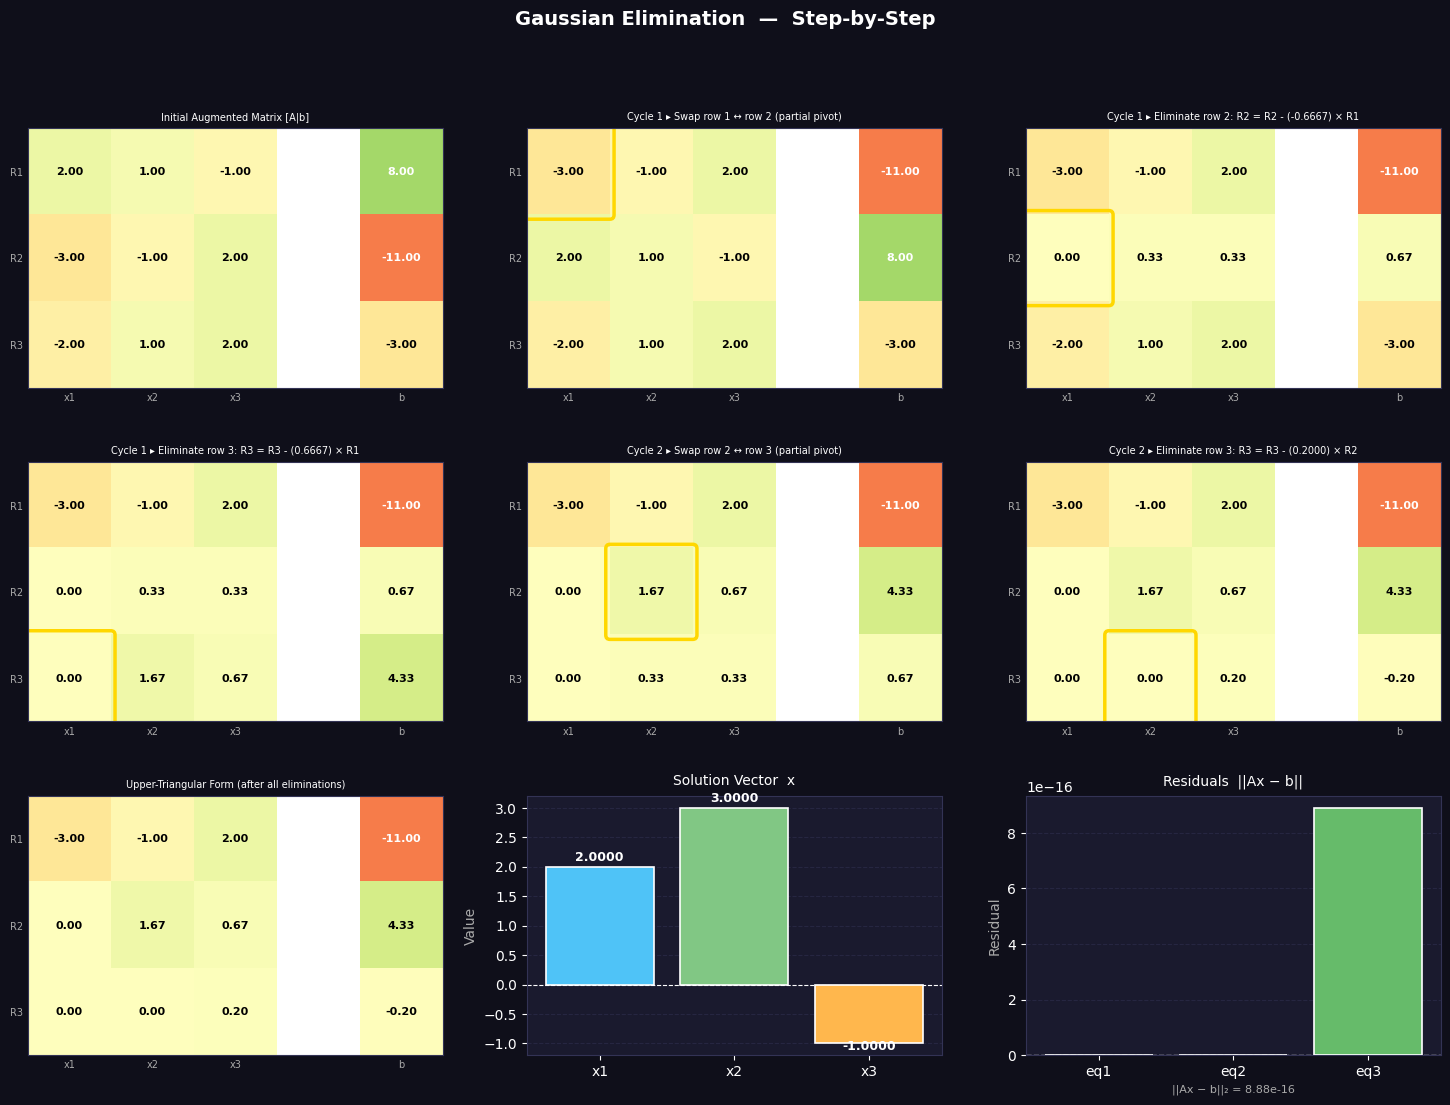


✅  Figure saved as  gauss_elimination_steps.png


In [1]:
"""
==============================================
  GAUSSIAN ELIMINATION - Google Colab Ready
==============================================
  Solves a system of linear equations Ax = b
  using forward elimination + back substitution
  with step-by-step output and visualization.
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from copy import deepcopy

# ─────────────────────────────────────────────
#  SETTINGS  (edit your matrix and vector here)
# ─────────────────────────────────────────────

A = [
    [2,  1, -1],
    [-3, -1,  2],
    [-2,  1,  2]
]

b = [8, -11, -3]

# ─────────────────────────────────────────────

def print_augmented(matrix, step_label=""):
    """Pretty-print the augmented matrix."""
    n = len(matrix)
    print(f"\n{'─'*50}")
    if step_label:
        print(f"  {step_label}")
    print(f"{'─'*50}")
    for row in matrix:
        formatted = "  │  " + "   ".join(f"{val:8.4f}" for val in row[:-1])
        formatted += "   │  " + f"{row[-1]:8.4f}"
        print(formatted)
    print(f"{'─'*50}")


def gaussian_elimination(A, b):
    """
    Performs Gaussian Elimination with Partial Pivoting.
    Returns the solution vector x and a history of matrix snapshots.
    """
    n = len(b)

    # Build augmented matrix [A | b]
    aug = [[A[i][j] for j in range(n)] + [b[i]] for i in range(n)]

    history = []   # stores (label, matrix_snapshot, pivot_row, pivot_col)

    # ── Initial state ──────────────────────────────────────────
    history.append(("Initial Augmented Matrix [A|b]",
                    deepcopy(aug), None, None))
    print_augmented(aug, "Initial Augmented Matrix [A|b]")

    # ── Forward Elimination ────────────────────────────────────
    for col in range(n):
        # --- Partial Pivoting ---
        max_row = col
        for row in range(col + 1, n):
            if abs(aug[row][col]) > abs(aug[max_row][col]):
                max_row = row

        if max_row != col:
            aug[col], aug[max_row] = aug[max_row], aug[col]
            label = f"Cycle {col+1} ▸ Swap row {col+1} ↔ row {max_row+1} (partial pivot)"
            history.append((label, deepcopy(aug), col, col))
            print_augmented(aug, label)

        # --- Eliminate below pivot ---
        pivot = aug[col][col]
        if abs(pivot) < 1e-12:
            raise ValueError(f"Zero pivot encountered at column {col+1}. "
                             "The system may be singular or require reordering.")

        for row in range(col + 1, n):
            if aug[row][col] == 0:
                continue
            factor = aug[row][col] / pivot
            for j in range(col, n + 1):
                aug[row][j] -= factor * aug[col][j]

            label = (f"Cycle {col+1} ▸ Eliminate row {row+1}: "
                     f"R{row+1} = R{row+1} - ({factor:.4f}) × R{col+1}")
            history.append((label, deepcopy(aug), row, col))
            print_augmented(aug, label)

    # ── Back Substitution ──────────────────────────────────────
    x = [0.0] * n
    print(f"\n{'═'*50}")
    print("  BACK SUBSTITUTION")
    print(f"{'═'*50}")

    for i in range(n - 1, -1, -1):
        x[i] = aug[i][n]
        for j in range(i + 1, n):
            x[i] -= aug[i][j] * x[j]
        x[i] /= aug[i][i]
        print(f"  x[{i+1}] = {x[i]:.6f}")

    history.append(("Upper-Triangular Form (after all eliminations)",
                    deepcopy(aug), None, None))

    return x, history


def visualize(history, solution, A_orig, b_orig):
    """
    Produces a multi-panel figure:
      • Heatmaps of each elimination cycle
      • Solution bar chart
      • Residual plot
    """
    n_snaps = len(history)
    cols    = 3
    rows    = (n_snaps + 1) // cols + 2   # extra rows for solution & residual

    fig = plt.figure(figsize=(cols * 5, rows * 3.5))
    fig.patch.set_facecolor("#0f0f1a")

    cmap = plt.cm.RdYlGn

    # ── Matrix heatmaps ────────────────────────────────────────
    for idx, (label, mat, p_row, p_col) in enumerate(history):
        ax = fig.add_subplot(rows, cols, idx + 1)
        arr = np.array(mat, dtype=float)
        n   = arr.shape[0]

        # Augmented matrix: split coefficients from RHS
        coeff = arr[:, :-1]
        rhs   = arr[:, -1:]
        full  = np.hstack([coeff, np.full((n, 1), np.nan), rhs])

        im = ax.imshow(full, cmap=cmap, aspect="auto",
                       vmin=-20, vmax=20, interpolation="nearest")

        # Cell labels
        for r in range(n):
            for c in range(n + 2):
                if c == n:          # separator column
                    ax.text(c, r, "│", ha="center", va="center",
                            color="white", fontsize=10, fontweight="bold")
                    continue
                val = full[r, c]
                if np.isnan(val):
                    continue
                txt_col = "black" if 0.3 < (val + 20) / 40 < 0.7 else "white"
                ax.text(c, r, f"{val:.2f}", ha="center", va="center",
                        color=txt_col, fontsize=8, fontweight="bold")

        # Highlight pivot cell
        if p_row is not None and p_col is not None:
            rect = mpatches.FancyBboxPatch(
                (p_col - 0.5, p_row - 0.5), 1, 1,
                boxstyle="round,pad=0.05",
                linewidth=2.5, edgecolor="#FFD700",
                facecolor="none"
            )
            ax.add_patch(rect)

        ax.set_title(label, color="white", fontsize=7, pad=6,
                     wrap=True)
        ax.set_xticks(range(n + 2))
        ax.set_xticklabels([f"x{i+1}" for i in range(n)] + ["", "b"],
                           color="#aaaaaa", fontsize=7)
        ax.set_yticks(range(n))
        ax.set_yticklabels([f"R{i+1}" for i in range(n)],
                           color="#aaaaaa", fontsize=7)
        ax.tick_params(length=0)
        for spine in ax.spines.values():
            spine.set_edgecolor("#333355")

    # ── Solution bar chart ──────────────────────────────────────
    ax_sol = fig.add_subplot(rows, cols, n_snaps + 1)
    vars_  = [f"x{i+1}" for i in range(len(solution))]
    colors = ["#4fc3f7", "#81c784", "#ffb74d",
              "#e57373", "#ba68c8", "#4dd0e1"]
    bars = ax_sol.bar(vars_, solution,
                      color=colors[:len(solution)],
                      edgecolor="white", linewidth=1.2,
                      zorder=3)
    for bar, val in zip(bars, solution):
        ax_sol.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + (0.05 if val >= 0 else -0.15),
                    f"{val:.4f}", ha="center", va="bottom",
                    color="white", fontsize=9, fontweight="bold")

    ax_sol.axhline(0, color="white", linewidth=0.8, linestyle="--")
    ax_sol.set_facecolor("#1a1a2e")
    ax_sol.set_title("Solution Vector  x", color="white", fontsize=10, pad=8)
    ax_sol.tick_params(colors="white")
    ax_sol.set_ylabel("Value", color="#aaaaaa")
    ax_sol.yaxis.label.set_color("#aaaaaa")
    for spine in ax_sol.spines.values():
        spine.set_edgecolor("#333355")
    ax_sol.grid(axis="y", color="#333355", linestyle="--", alpha=0.5, zorder=0)

    # ── Residual plot  Ax - b ───────────────────────────────────
    ax_res = fig.add_subplot(rows, cols, n_snaps + 2)
    A_np  = np.array(A_orig, dtype=float)
    b_np  = np.array(b_orig, dtype=float)
    x_np  = np.array(solution)
    residuals = A_np @ x_np - b_np

    res_colors = ["#ef5350" if r < 0 else "#66bb6a" for r in residuals]
    ax_res.bar([f"eq{i+1}" for i in range(len(residuals))],
               residuals,
               color=res_colors,
               edgecolor="white", linewidth=1.2, zorder=3)
    ax_res.axhline(0, color="white", linewidth=1, linestyle="--")
    ax_res.set_facecolor("#1a1a2e")
    ax_res.set_title("Residuals  ||Ax − b||", color="white",
                     fontsize=10, pad=8)
    ax_res.tick_params(colors="white")
    ax_res.set_ylabel("Residual", color="#aaaaaa")
    for spine in ax_res.spines.values():
        spine.set_edgecolor("#333355")
    ax_res.grid(axis="y", color="#333355", linestyle="--", alpha=0.5, zorder=0)

    norm_res = float(np.linalg.norm(residuals))
    ax_res.set_xlabel(f"||Ax − b||₂ = {norm_res:.2e}",
                      color="#aaaaaa", fontsize=8)

    # ── Global title ─────────────────────────────────────────────
    fig.suptitle("Gaussian Elimination  —  Step-by-Step",
                 color="white", fontsize=14, fontweight="bold", y=1.01)

    plt.tight_layout(pad=2.5)
    plt.savefig("gauss_elimination_steps.png",
                dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show()
    print("\n✅  Figure saved as  gauss_elimination_steps.png")


# ──────────────────────────────────────────────────────────────
#  MAIN
# ──────────────────────────────────────────────────────────────

def main():
    print("\n" + "═"*50)
    print("  GAUSSIAN ELIMINATION  (with Partial Pivoting)")
    print("═"*50)

    n = len(b)
    print(f"\n  System size : {n} × {n}")
    print("\n  Coefficient matrix A:")
    for row in A:
        print("   ", row)
    print("\n  Right-hand side b:", b)

    try:
        solution, history = gaussian_elimination(A, b)

        print(f"\n{'═'*50}")
        print("  SOLUTION")
        print(f"{'═'*50}")
        for i, val in enumerate(solution):
            print(f"  x[{i+1}] = {val:.6f}")

        # Verification
        print(f"\n{'─'*50}")
        print("  VERIFICATION  (Ax should equal b)")
        print(f"{'─'*50}")
        A_np = np.array(A, dtype=float)
        b_np = np.array(b, dtype=float)
        x_np = np.array(solution)
        Ax   = A_np @ x_np
        for i in range(n):
            status = "✓" if abs(Ax[i] - b_np[i]) < 1e-8 else "✗"
            print(f"  {status}  Eq {i+1}: Ax = {Ax[i]:.6f}  |  b = {b_np[i]:.6f}  "
                  f"|  err = {abs(Ax[i]-b_np[i]):.2e}")

        visualize(history, solution, A, b)

    except ValueError as e:
        print(f"\n❌  Error: {e}")


main()